# Phase 4 — First Full Budget Simulation

This notebook runs the Monte Carlo simulation engine on the budget model,
validates that the sample mean matches the analytical $E[X_{\text{total}}]$,
and produces the first publication-quality histogram.

In [1]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

from src.model import BudgetModel
from src.monte_carlo import MonteCarloSimulator
from src.analysis import compute_ci, prob_over_budget, summary_stats

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

## 1. Setup and Analytical Reference

In [2]:
model = BudgetModel()
E_analytical = model.analytical_expected_total()
Var_analytical = model.analytical_variance_total()
SD_analytical = np.sqrt(Var_analytical)

print("=== Analytical Reference (Phase 1) ===")
print(f"E[X_total]  = R$ {E_analytical:>14,.2f}")
print(f"SD[X_total] = R$ {SD_analytical:>14,.2f}")

=== Analytical Reference (Phase 1) ===
E[X_total]  = R$  11,544,339.11
SD[X_total] = R$     492,150.60


## 2. Run Monte Carlo Simulation

In [3]:
simulator = MonteCarloSimulator(
    cost_fn=lambda rng: model.simulate_one_year(rng).total_cost
)

result = simulator.run(n_iterations=10_000, seed=42)

print(f"=== Monte Carlo Results (N = {result.n_iterations:,}) ===")
print(f"Sample mean = R$ {result.mean:>14,.2f}")
print(f"Sample SD   = R$ {result.std:>14,.2f}")
print(f"MC Std Error= R$ {result.standard_error:>14,.2f}")

=== Monte Carlo Results (N = 10,000) ===
Sample mean = R$  11,536,784.47
Sample SD   = R$     488,634.56
MC Std Error= R$       4,886.35


## 3. Validation: Analytical vs Monte Carlo

In [4]:
rel_error_mean = abs(result.mean - E_analytical) / E_analytical
rel_error_sd = abs(result.std - SD_analytical) / SD_analytical

print("=== Validation ===")
print(f"{'':30} {'Analytical':>14}  {'MC':>14}  {'Rel Error':>10}")
print(f"{'E[X_total]':30} {E_analytical:>14,.2f}  {result.mean:>14,.2f}  {rel_error_mean:>10.4%}")
print(f"{'SD[X_total]':30} {SD_analytical:>14,.2f}  {result.std:>14,.2f}  {rel_error_sd:>10.4%}")
print()

# Check: sample mean within CI of analytical
ci_lo, ci_hi = compute_ci(result.samples, alpha=0.05)
contains = ci_lo <= E_analytical <= ci_hi
print(f"95% CI: [R$ {ci_lo:,.0f}, R$ {ci_hi:,.0f}]")
print(f"CI contains analytical E[X]: {contains}")
print(f"CI half-width: R$ {(ci_hi - ci_lo)/2:,.0f}")

=== Validation ===
                                   Analytical              MC   Rel Error
E[X_total]                      11,544,339.11   11,536,784.47     0.0654%
SD[X_total]                        492,150.60      488,634.56     0.7144%

95% CI: [R$ 11,527,207, R$ 11,546,362]
CI contains analytical E[X]: True
CI half-width: R$ 9,577


## 4. Summary Statistics

In [5]:
ss = summary_stats(result.samples)

print("=== Summary Statistics ===")
for key in ["mean", "std", "se", "median", "p5", "p25", "p75", "p95", "min", "max"]:
    print(f"{key:>8}: R$ {ss[key]:>14,.2f}")
print(f"{'skewness':>8}: {ss['skewness']:>14.4f}")
print(f"{'kurtosis':>8}: {ss['kurtosis']:>14.4f}")

=== Summary Statistics ===
    mean: R$  11,536,784.47
     std: R$     488,634.56
      se: R$       4,886.35
  median: R$  11,526,407.80
      p5: R$  10,756,249.92
     p25: R$  11,199,045.25
     p75: R$  11,863,716.67
     p95: R$  12,360,768.91
     min: R$   9,925,152.38
     max: R$  13,534,614.56
skewness:         0.1529
kurtosis:         0.0346


## 5. Overbudget Probability

In [6]:
budget_ceiling = 12_500_000
p_over = prob_over_budget(result.samples, budget_ceiling)

print(f"Budget ceiling: R$ {budget_ceiling:,.0f}")
print(f"P(X > ceiling): {p_over:.2%}")
print(f"P(X ≤ ceiling): {1 - p_over:.2%}")

Budget ceiling: R$ 12,500,000
P(X > ceiling): 2.74%
P(X ≤ ceiling): 97.26%


## 6. Budget Cost Histogram

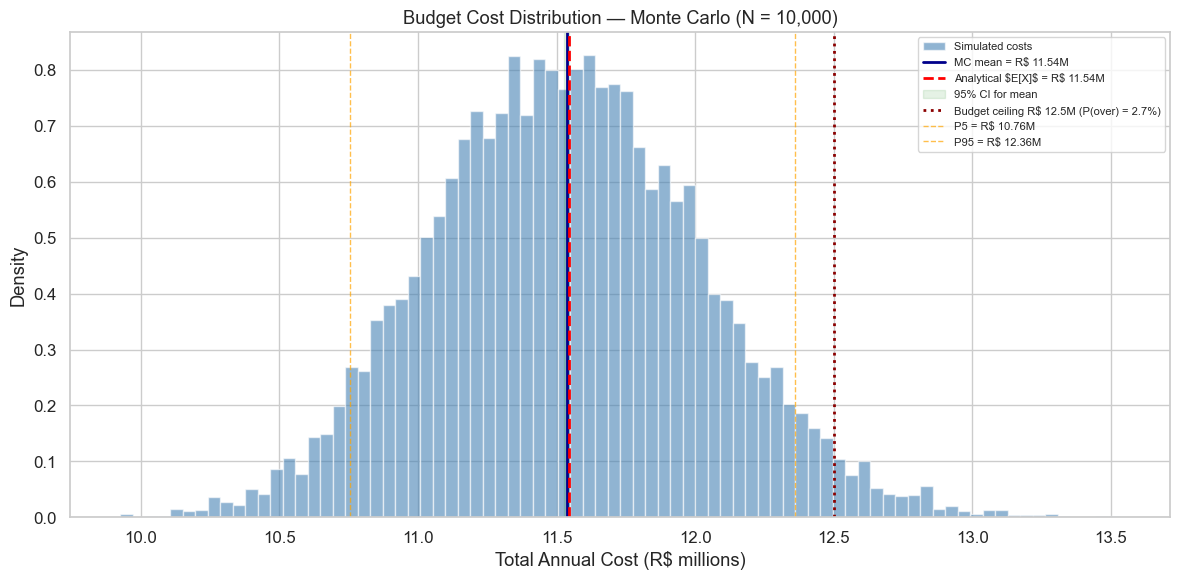

Saved: figures/budget_histogram.png


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

# Histogram
ax.hist(result.samples / 1e6, bins=80, density=True, alpha=0.6,
        color="steelblue", edgecolor="white", label="Simulated costs")

# Mean
ax.axvline(result.mean / 1e6, color="darkblue", ls="-", lw=2,
           label=f"MC mean = R$ {result.mean/1e6:.2f}M")

# Analytical mean
ax.axvline(E_analytical / 1e6, color="red", ls="--", lw=2,
           label=f"Analytical $E[X]$ = R$ {E_analytical/1e6:.2f}M")

# 95% CI
ax.axvspan(ci_lo / 1e6, ci_hi / 1e6, alpha=0.1, color="green",
           label=f"95% CI for mean")

# Budget ceiling
ax.axvline(budget_ceiling / 1e6, color="darkred", ls=":", lw=2,
           label=f"Budget ceiling R$ {budget_ceiling/1e6:.1f}M "
                 f"(P(over) = {p_over:.1%})")

# Percentiles
ax.axvline(ss["p5"] / 1e6, color="orange", ls="--", lw=1, alpha=0.7,
           label=f"P5 = R$ {ss['p5']/1e6:.2f}M")
ax.axvline(ss["p95"] / 1e6, color="orange", ls="--", lw=1, alpha=0.7,
           label=f"P95 = R$ {ss['p95']/1e6:.2f}M")

ax.set_xlabel("Total Annual Cost (R$ millions)")
ax.set_ylabel("Density")
ax.set_title(f"Budget Cost Distribution — Monte Carlo (N = {result.n_iterations:,})")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig("../figures/budget_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/budget_histogram.png")

## 7. Component Breakdown

In [8]:
# Re-run with detailed results
rng = np.random.default_rng(42)
detailed = [model.simulate_one_year(rng) for _ in range(10_000)]

salary_costs = np.array([r.salary_cost for r in detailed])
overtime_costs = np.array([r.overtime_cost for r in detailed])
incident_costs = np.array([r.incident_cost for r in detailed])

print("=== Component Means ===")
print(f"Salary:   R$ {salary_costs.mean():>14,.2f}  ({salary_costs.mean()/result.mean*100:.1f}%)")
print(f"Overtime: R$ {overtime_costs.mean():>14,.2f}  ({overtime_costs.mean()/result.mean*100:.1f}%)")
print(f"Incident: R$ {incident_costs.mean():>14,.2f}  ({incident_costs.mean()/result.mean*100:.1f}%)")

=== Component Means ===
Salary:   R$  11,173,026.30  (96.8%)
Overtime: R$     240,045.29  (2.1%)
Incident: R$     123,712.88  (1.1%)


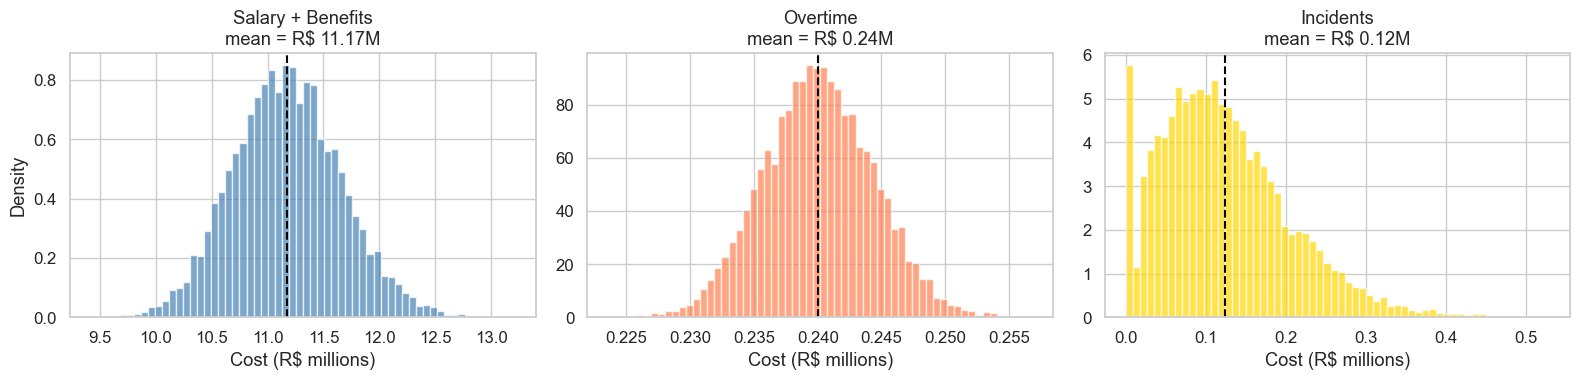

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, data, title, color in zip(
    axes,
    [salary_costs, overtime_costs, incident_costs],
    ["Salary + Benefits", "Overtime", "Incidents"],
    ["steelblue", "coral", "gold"],
):
    ax.hist(data / 1e6, bins=60, density=True, alpha=0.7,
            color=color, edgecolor="white")
    ax.axvline(data.mean() / 1e6, color="black", ls="--", lw=1.5)
    ax.set_xlabel("Cost (R$ millions)")
    ax.set_title(f"{title}\nmean = R$ {data.mean()/1e6:.2f}M")

axes[0].set_ylabel("Density")
plt.tight_layout()
plt.savefig("../figures/budget_components.png", dpi=150, bbox_inches="tight")
plt.show()

## Key Takeaways

1. **Validation passed.** The MC sample mean is within <1% of the
   analytical $E[X_{\text{total}}]$ and the 95% CI contains it.

2. **The distribution is right-skewed.** The LogNormal salary component
   dominates, pulling the distribution rightward. Mean > median.

3. **Overbudget risk is quantifiable.** With a ceiling of R\$ 12.5M,
   the simulation gives a concrete $P(\text{over})$.

4. **Salaries dominate.** ~97% of both cost and variance comes from
   the salary component. Overtime and incidents are small contributors.

### What a point estimate misses

A spreadsheet gives "R\$ 11.55M". Monte Carlo gives:
- A full distribution with shape information
- R$ 11.55M ± R$ X (confidence interval)
- P(over budget) = Y%
- Percentile range [P5, P95] for planning

This is the value proposition of the article.